In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree  

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Load dữ liệu
---

In [3]:
diabetes = pd.read_csv('./diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
diabetes.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Làm sạch dữ liệu
---

In [4]:
# Kiểm tra các giá trị trùng lăp
# In ra tổng các hàng trong dữ liệu
print('Tổng số hàng:', diabetes.shape[0])
print('Các giá trị trùng lăp:', diabetes.duplicated().sum())

Tổng số hàng: 70692
Các giá trị trùng lăp: 1635


#### Có thể thấy dữ liệu đang có 1635 hàng trùng lặp nên tiến hành xóa các giá trị trùng lặp để tránh ảnh hướng xấu đến mô hình

In [5]:
# Xóa giá trị trùng lặp
diabetes.drop_duplicates(inplace=True) 
print('Tổng số hàng còn lại sau khi xóa: ', diabetes.shape[0])

Tổng số hàng còn lại sau khi xóa:  69057


In [6]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69057 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       69057 non-null  float64
 1   HighBP                69057 non-null  float64
 2   HighChol              69057 non-null  float64
 3   CholCheck             69057 non-null  float64
 4   BMI                   69057 non-null  float64
 5   Smoker                69057 non-null  float64
 6   Stroke                69057 non-null  float64
 7   HeartDiseaseorAttack  69057 non-null  float64
 8   PhysActivity          69057 non-null  float64
 9   Fruits                69057 non-null  float64
 10  Veggies               69057 non-null  float64
 11  HvyAlcoholConsump     69057 non-null  float64
 12  AnyHealthcare         69057 non-null  float64
 13  NoDocbcCost           69057 non-null  float64
 14  GenHlth               69057 non-null  float64
 15  MentHlth              69

#### Kiểm tra thông tin của bộ dữ liệu có thế thấy các hàng không có giá trị thiếu và kiểu dữ liệu của bộ dữ liệu cũng đã đồng nhất

In [7]:
# Kiểm tra tính đồng nhất của các cột
unique_counts = diabetes.nunique()
print(unique_counts)

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


#### Kiểm tra tính đồng nhất của các cột dữ liệu thì có thể thấy dữ liệu đã đúng với mô tả không có cột nào chưa đồng nhất 


array([[<Axes: title={'center': 'Diabetes_binary'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title=

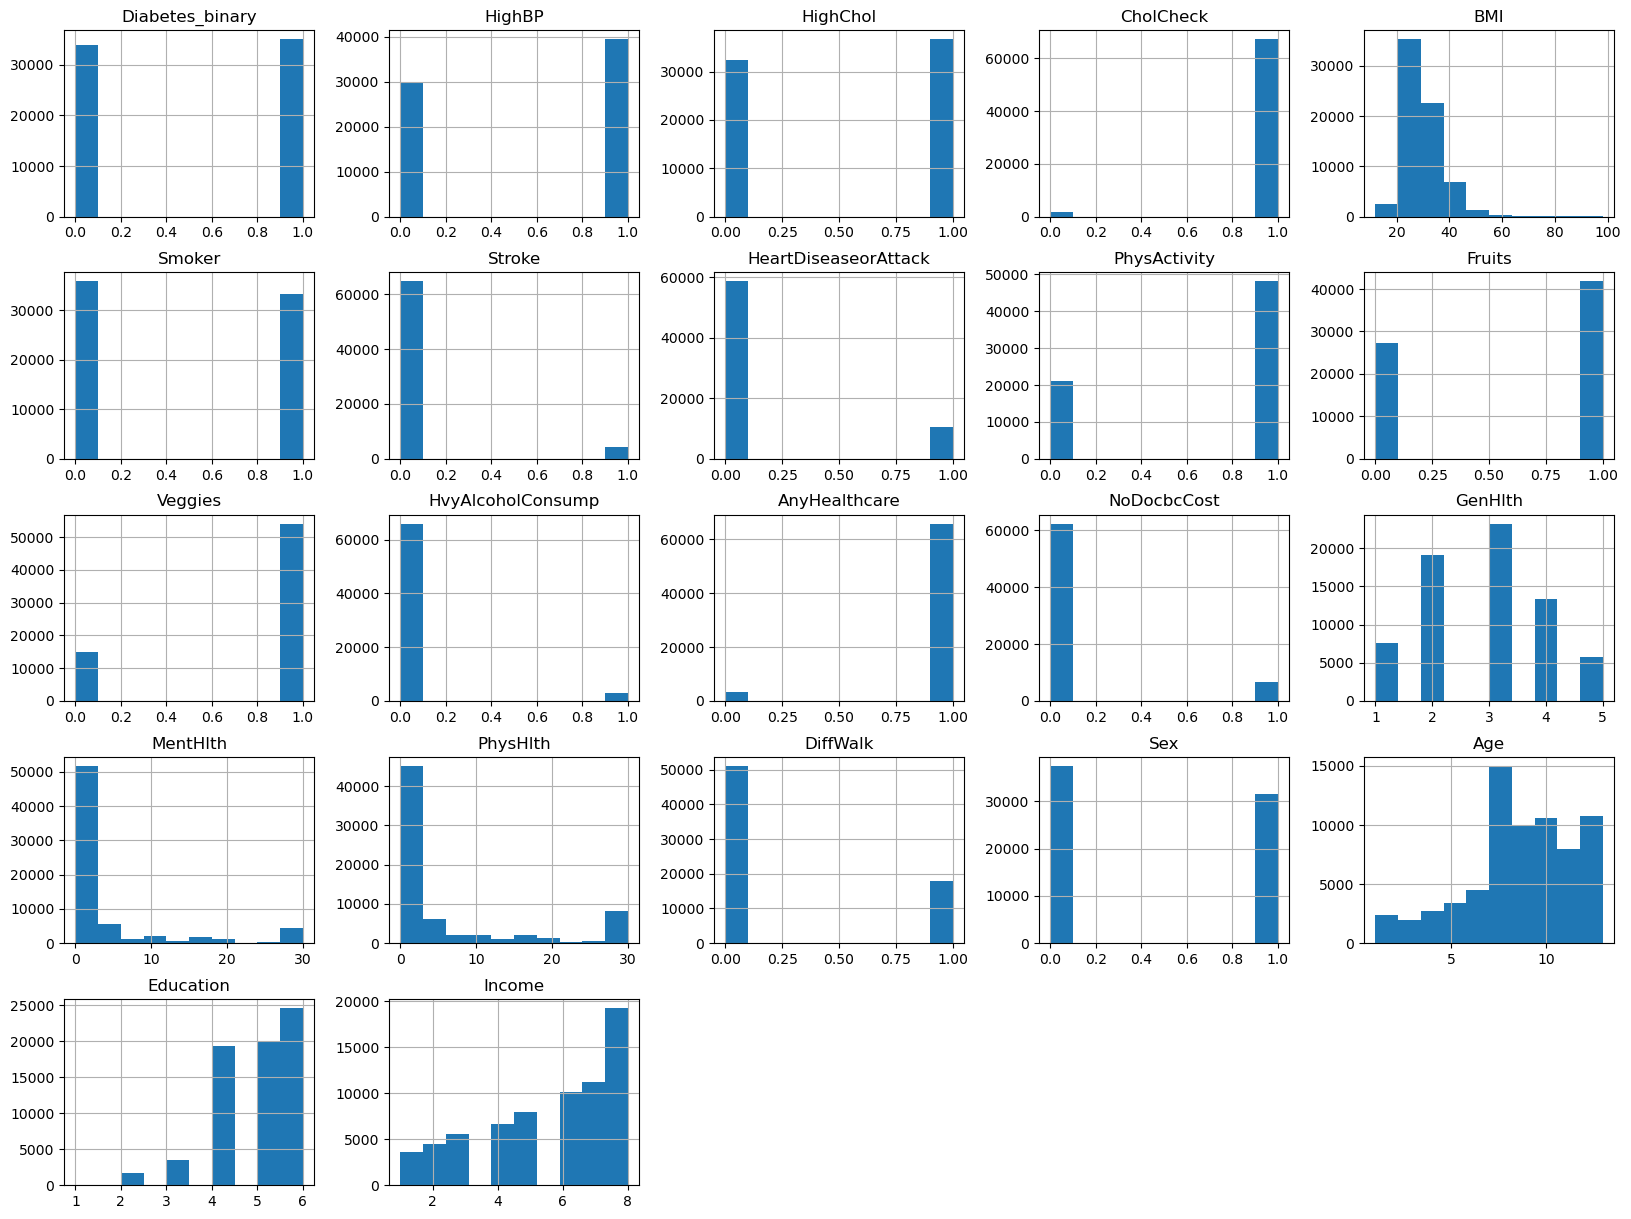

In [8]:
diabetes.hist(figsize=(20, 15))

#### Kiểm tra phân phối của các cột dữ liệu có thể thấy rằng một số cột đang có phân phối dữ liệu không đều và cột BMI đang có dấu hiệu bất thường

In [9]:
diabetes.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,...,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000,69057.000000
mean,0.508232,0.571224,0.531329,0.974803,29.955834,0.481935,0.063643,0.150875,0.696483,0.605659,...,0.953908,0.096138,2.863692,3.840103,5.945306,0.258612,0.456464,8.604037,4.900285,5.651332
std,0.499936,0.494905,0.499021,0.156723,7.147972,0.499677,0.244118,0.357930,0.459780,0.488712,...,0.209687,0.294782,1.107950,8.231164,10.139113,0.437875,0.498105,2.858284,1.029338,2.175608
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,1.000000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,3.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


#### Kiểm tra lại thì có thể thấy rằng cột BMI đang có giá trị ngoại lai 

<Axes: ylabel='Count'>

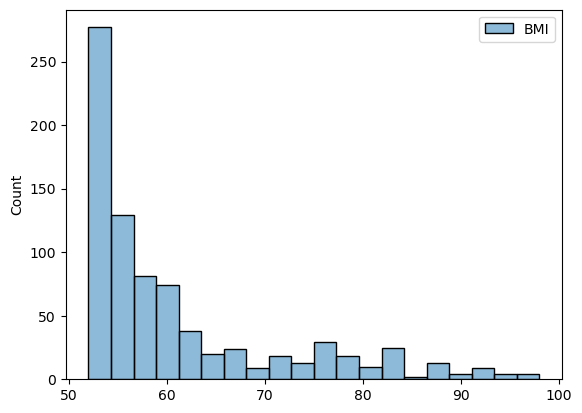

In [10]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Tính toán z-score cho cột BMI
diabetes['z_score_bmi'] = stats.zscore(diabetes['BMI'], ddof=1)

# Lọc ra các giá trị ngoại lai trong cột BMI
data_outliers= diabetes[(diabetes['z_score_bmi'] > 3) | (diabetes['z_score_bmi'] < -3)][['z_score_bmi']]

# In ra giá trị của cột BMI của các giá trị ngoại lai
sns.histplot(diabetes[(diabetes['z_score_bmi'] > 3) | (diabetes['z_score_bmi'] < -3)][['BMI']])


In [11]:
print(f"Số lượng giá trị ngoại lai: {len(data_outliers)}")
outlier_ratio = len(data_outliers) / 69057
print(f"Tỷ lệ giá trị ngoại lai: {outlier_ratio:.2%}")

Số lượng giá trị ngoại lai: 801
Tỷ lệ giá trị ngoại lai: 1.16%


#### Trong thực tế mặc dù rất hiếm nhưng vẫn có người BMI từ 50 - 100, các giá trị ngoại lai cũng chỉ chiểm hơn 1% trong cột dữ liệu nên sẽ không ảnh hưởng nhiều đến mô hình. Ngoài ra việc giữ lại những chỉ số này cũng làm đa dạng hơn cho mô hình phản ánh đúng với thực tế

In [12]:
diabetes.drop(columns=['z_score_bmi'], inplace=True)

#### Xóa cột z_score_bmi sau khi đã xong bước kiểm tra ngoại lai

## Feature Creation 
---

In [13]:
diabetes_copy = diabetes.copy()

diabetes_copy['BMI_Age'] = diabetes_copy['BMI'] * diabetes_copy['Age']
diabetes_copy['GenHlth_PhysActivity'] = diabetes_copy['GenHlth'] * diabetes_copy['PhysActivity']
diabetes_copy['Ment_Phys_Health_Score'] = diabetes_copy['MentHlth'] + diabetes_copy['PhysHlth']

diabetes_copy.drop(columns=['BMI', 'Age', 'GenHlth', 'PhysActivity', 'MentHlth', 'PhysHlth'], inplace=True)

#### BMI × Age: Biến số biểu thị ảnh hưởng của chỉ số khối cơ thể theo độ tuổi.<br>GenHlth × PhysActivity: Mức độ sức khỏe chung kết hợp với mức độ vận động thể chất.<br>Ment_Phys_Health_Score: Tổng hợp sức khỏe tâm lý và thể chất.<br>
#### Copy một biến lưu dữ liệu mới để giữ lại các biến đặc trưng của tệp dữ liệu cũ


In [14]:
X_old = diabetes.drop('Diabetes_binary', axis=1)
y_old = diabetes['Diabetes_binary']

X_train_old, X_test_old, y_train_old, y_test_old = train_test_split(X_old, y_old, test_size=0.3, random_state=42)

X_new = diabetes_copy.drop('Diabetes_binary', axis=1)
y_new = diabetes_copy['Diabetes_binary']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

#### Chia tệp dữ liệu cũ và tệp dữ liệu mới khi thêm biến mới để thử nghiệm 

In [15]:
# Huấn luyện mô hình trước khi tạo biến mới
model_old = DecisionTreeClassifier(random_state=42)
model_old.fit(X_train_old, y_train_old)
y_pred_old = model_old.predict(X_test_old)

# Huấn luyện mô hình sau khi ta đã tạo biến mới
model_new = DecisionTreeClassifier(random_state=42)
model_new.fit(X_train_new, y_train_new)
y_pred_new = model_new.predict(X_test_new)

# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_all = recall_score(y_test_old, y_pred_old)
precision_all = precision_score(y_test_old, y_pred_old)
f1_all = f1_score(y_test_old, y_pred_old)
accuracy_all = accuracy_score(y_test_old, y_pred_old)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_selected = recall_score(y_test_new, y_pred_new)
precision_selected = precision_score(y_test_new, y_pred_new)
f1_selected = f1_score(y_test_new, y_pred_new)
accuracy_selected = accuracy_score(y_test_new, y_pred_new)

# So sánh kết quả
comparison = pd.DataFrame({
    'Model': ['OLD', 'NEW'],
    'Recall': [recall_all, recall_selected],
    'Precision': [precision_all, precision_selected],
    'F1 Score': [f1_all, f1_selected],
    'Accuracy': [accuracy_all, accuracy_selected]
})

print(comparison)

  Model    Recall  Precision  F1 Score  Accuracy
0   OLD  0.645499   0.659882  0.652611  0.648470
1   NEW  0.633138   0.656042  0.644387  0.642533


#### Nhìn vào các chỉ só có thể thấy rằng các biến mới không mang lại nhiều lợi ích cho mô hình nên sẽ vẫn giữ các biến như ban đầu

## Feature Transformation
---

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

scaler_stand = StandardScaler()
diabetes[['BMI']] = scaler_stand.fit_transform(diabetes[['BMI']])

scaler_nomal = MinMaxScaler()
diabetes[['HighBP', 'GenHlth', 'Age', 'Education', 'Income']] = scaler_nomal.fit_transform(diabetes[['HighBP', 'GenHlth', 'Age', 'Education', 'Income']])

diabetes.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,-0.553424,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.50,5.0,30.0,0.0,1.0,0.250000,1.0,1.0
1,0.0,1.0,1.0,1.0,-0.553424,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.50,0.0,0.0,0.0,1.0,0.916667,1.0,1.0
2,0.0,0.0,0.0,1.0,-0.553424,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.00,0.0,10.0,0.0,1.0,1.000000,1.0,1.0
3,0.0,1.0,1.0,1.0,-0.273623,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.50,0.0,3.0,0.0,1.0,0.833333,1.0,1.0
4,0.0,0.0,0.0,1.0,-0.133722,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.25,0.0,0.0,0.0,0.0,0.583333,0.8,1.0


#### Ở đây chỉ duy nhất cột BMI có phân phối chuẩn còn lại các cột đều có phần phối không chuẩn vậy nên chỉ áp dụng StandardScaler cho cột BMI 

## Huấn luyện mô hình
---

In [17]:
X = diabetes.drop('Diabetes_binary', axis=1)
y = diabetes['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Chia tệp dữ liệu theo tỷ lệ 3 test và 7 train

In [18]:
decision_tree= DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

dt_pred_test = decision_tree.predict(X_test)
dt_pred_train = decision_tree.predict(X_train)

#### Chạy mô hình và kiểm tra kết quả trên cả 2 tập dữ liệu để đánh giá mô hình

Text(0.5, 1.0, 'Confusion Matrix Train ')

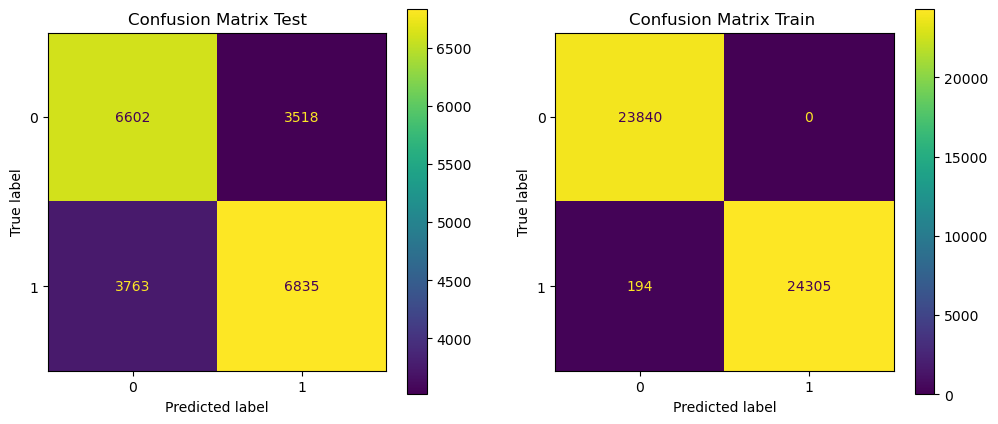

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, dt_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_test.plot(ax=axes[0])
axes[0].set_title('Confusion Matrix Test')

# Plot confusion matrix for train set
cm_train = confusion_matrix(y_train, dt_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[1])
axes[1].set_title('Confusion Matrix Train ')


In [20]:
# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_test = recall_score(y_test, dt_pred_test)
precision_test = precision_score(y_test, dt_pred_test)
f1_test = f1_score(y_test, dt_pred_test)
accuracy_test = accuracy_score(y_test, dt_pred_test)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_train = recall_score(y_train, dt_pred_train)
precision_train = precision_score(y_train, dt_pred_train)
f1_train= f1_score(y_train, dt_pred_train)
accuracy_train = accuracy_score(y_train, dt_pred_train)

# So sánh kết quả
comparison = pd.DataFrame({
    '': ['Test' , 'Train'],
    'Recall': [recall_test, recall_train],
    'Precision': [precision_test, precision_train],
    'F1 Score': [f1_test, f1_train],
    'Accuracy': [accuracy_test, accuracy_train]
})

print(comparison)

            Recall  Precision  F1 Score  Accuracy
0   Test  0.644933   0.660195  0.652475  0.648566
1  Train  0.992081   1.000000  0.996025  0.995987


#### Nhìn vào biểu đồ cũng như các chỉ số có thể thấy mô hình đang bị tình trạng overfitting 

## Hyperparameter Tuning 
---

In [21]:
tree_para = {'max_depth':[ 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
             'min_samples_leaf':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

scoring = {'f1', 'precision', 'recall', 'accuracy'}

In [22]:
from sklearn.model_selection import GridSearchCV

tuned_decision_tree = DecisionTreeClassifier(random_state=42)

clf = GridSearchCV(tuned_decision_tree, tree_para, cv=5, scoring=list(scoring), refit='f1')

clf.fit(X_train, y_train)
clf.best_estimator_

DecisionTreeClassifier(max_depth=7, random_state=42)

#### Áp dụng GridSearchCV để tìm ra mô hình tốt nhất <br> Vì đề tài làm về y tế nên sẽ tìm ra mô hình có chỉ số F1 cao nhất thay vì độ chính xác.<br>
#### Lý do chọn F1 là: <br> Mô hình sẽ cần chỉ số Recall cao để tránh bỏ sót các trường hợp bị tiểu đường nhưng mô hình lại dự đoán là không. <br> Mô hình cũng sẽ cần chỉ số Precision cao để tránh chẩn đoán nhầm khiến người kiểm tra hoang mang hoặc tốn tài nguyên điều trị sớm <br> F1 là chỉ số cân bằng giữa 2 chỉ số trên nên sẽ refit F1. <br> Trong bài toán y tế thì độ chính xác không đủ để đưa ra đánh giá chính xác cho người bệnh

<Axes: >

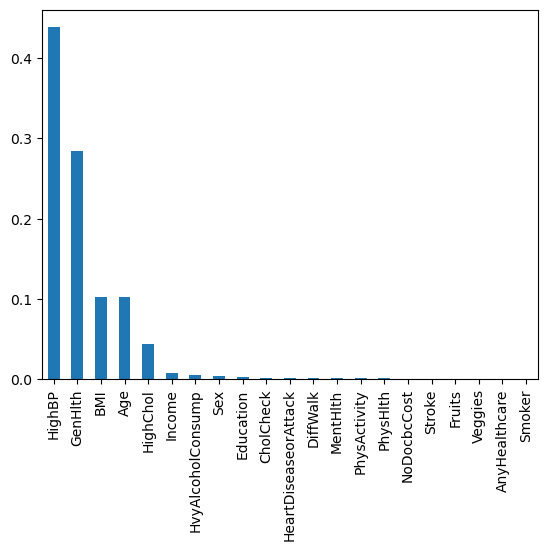

In [23]:
importances = clf.best_estimator_.feature_importances_

dt_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
dt_importances.plot.bar(ax=ax)

In [24]:
X = diabetes[['HighBP', 'GenHlth', 'BMI', 'Age', 'HighChol','Income','HvyAlcoholConsump','Sex','Education','CholCheck']]
y = diabetes['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Dựa trên bảng thống kê mức quan trọng của các biến có thể chọn ra 10 biến tốt nhất để chạy lại mô hình

In [25]:
from sklearn.model_selection import GridSearchCV

tree_para = {'max_depth':[ 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
             'min_samples_leaf':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}

scoring = {'f1', 'precision', 'recall', 'accuracy'}

In [26]:
tuned_decision_tree = DecisionTreeClassifier(random_state=42)

clf = GridSearchCV(tuned_decision_tree, tree_para, cv=10, scoring=list(scoring), refit='f1')

clf.fit(X_train, y_train)
clf.best_estimator_

DecisionTreeClassifier(max_depth=9, random_state=42)

In [27]:
decision_tree= DecisionTreeClassifier(random_state=42 , max_depth= 9)

decision_tree.fit(X_train, y_train)

dt_pred_test = decision_tree.predict(X_test)
dt_pred_train = decision_tree.predict(X_train)

#### Chạy lại mô hình với giá trị max_depth = 9 và min_samples_leaf mặc định bằng 0

Text(0.5, 1.0, 'Confusion Matrix Train ')

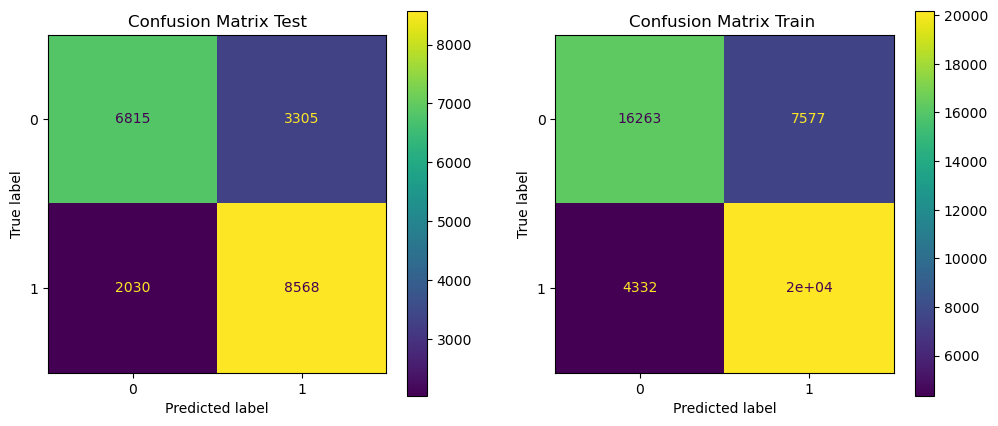

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for test set
cm = confusion_matrix(y_test, dt_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm)
disp_test.plot(ax=axes[0])
axes[0].set_title('Confusion Matrix Test')

# Plot confusion matrix for train set
cm_train = confusion_matrix(y_train, dt_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(ax=axes[1])
axes[1].set_title('Confusion Matrix Train ')


In [29]:
# Đánh giá mô hình trên tập dữ liệu đầy đủ
recall_test = recall_score(y_test, dt_pred_test)
precision_test = precision_score(y_test, dt_pred_test)
f1_test = f1_score(y_test, dt_pred_test)
accuracy_test = accuracy_score(y_test, dt_pred_test)

# Đánh giá mô hình trên tập dữ liệu đã chọn
recall_train = recall_score(y_train, dt_pred_train)
precision_train = precision_score(y_train, dt_pred_train)
f1_train= f1_score(y_train, dt_pred_train)
accuracy_train = accuracy_score(y_train, dt_pred_train)

# So sánh kết quả
comparison = pd.DataFrame({
    '': ['Test' , 'Train'],
    'Recall': [recall_test, recall_train],
    'Precision': [precision_test, precision_train],
    'F1 Score': [f1_test, f1_train],
    'Accuracy': [accuracy_test, accuracy_train]
})

print(comparison)

            Recall  Precision  F1 Score  Accuracy
0   Test  0.808454   0.721637  0.762583  0.742494
1  Train  0.823176   0.726896  0.772046  0.753636


#### Nhìn vào biểu đồ và các chỉ số trên khi chạy mô hình trên 2 tập dữ liệu train và test có thể thấy được rằng mô hình đã không còn bị overfitting kèm theo đó các chỉ số đặc biệt là F1 cũng tăng lên so với mô hình ban đầu

In [32]:
import pickle
pickle.dump(decision_tree, open('mo_hinh_du_doan_tieu_duong.pickle', 'wb'))

# Nhận xét chung

#### Nhìn chung thì mô hình cũng khá tốt. Tuy nhiên vẫn chưa đủ để áp dụng vào thực tế <br> Mô hình cũng cho thấy được các yếu tố ảnh hưởng đến bệnh tiểu đường chủ yểu là: Huyết áp, tình trạng sức khỏe chung, chỉ số BMI, cholesterol và độ tuổi còn lại các yếu tố khác ảnh hưởng khá ít tới mô hình <br>
